In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn.functional as F
from scipy.signal import *
import os
from pathlib import Path

In [2]:
collectedCSV  = glob("vctk/gen/csv/wav48_silence_trimmed/*/*.csv")
collectedFLAC = [csv.replace("vctk/gen/csv", "vctk/stock").replace("csv", "flac") for csv in collectedCSV]
exportedFLAC = [csv.replace("vctk/gen/csv", "vctk/gen/flac").replace("csv", "flac") for csv in collectedCSV]
Fs = 16000

#print(torchaudio.utils.sox_utils.list_read_formats())
print(torchaudio.list_audio_backends())
torch.backends.cuda.is_built()

['ffmpeg', 'sox', 'soundfile']


True

In [3]:
Ls = []
for flac_fn in tqdm(collectedFLAC):
    flacData, sr = torchaudio.load(flac_fn)
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    L = flacData.shape[-1]
    Ls.append(L)
maxLen = max(Ls)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8942/8942 [00:57<00:00, 156.32it/s]


In [6]:
def getSpectrum(signal, maxLen):
    signal = F.pad(signal, (0, maxLen - signal.shape[-1]))
    signal = signal / torch.sqrt(torch.sum(signal ** 2))
    signalSpec = torch.fft.rfft(signal).abs()
    return signalSpec

def loadFlac(flac_fn):
    flacData, sr = torchaudio.load(flac_fn)
    # resample to Fs
    flacData = torchaudio.transforms.Resample(sr, Fs)(flacData)
    return flacData[0, :]

In [7]:
N = 200 # Sample 200 poitns for approximating the spectrum
gtSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # ground truth spectrum
mouseXSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum
mouseYSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64) # mouse spectrum

pbar = tqdm(total=N)
for csv_fn, flac_fn in zip(collectedCSV[:N], collectedFLAC[:N]):
    # Load mouse data
    _, X, Y = processFromFile(csv_fn, maxTimesteps= None, skipPCA = True)
    
    # Load ground truth
    groundTruth = loadFlac(flac_fn)
    
    # Pad, FFT, normalize, and accumulate
    gtSpec += getSpectrum(groundTruth, maxLen) / N # divide here instead of outside the loop to avoid numerical issues (common when N is large)
    mouseXSpec += getSpectrum(X, maxLen) / N
    mouseYSpec += getSpectrum(Y, maxLen) / N
    
    pbar.update(1)
pbar.close()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:15<00:00, 12.62it/s]


In [8]:
maxLen

226209

In [9]:
_, noiseX, noiseY = processFromFile("vctk/noise/noise.csv", skipPCA = True)
k = torch.ceil(torch.tensor(noiseX.shape[0] / maxLen, dtype=torch.long)).item()
xz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
xz = noiseX[:xz.shape[0]]
xz = xz.reshape((k, maxLen))
yz = torch.zeros((k * maxLen, ), dtype=torch.complex64)
yz = noiseY[:yz.shape[0]]
yz = yz.reshape((k, maxLen))
xzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
yzSpec = torch.zeros(maxLen//2 + 1, dtype=torch.complex64)
for x, y in zip(xz, yz):
    xzSpec += getSpectrum(x, maxLen) / k
    yzSpec += getSpectrum(y, maxLen) / k

/home/tsu/.local/lib/python3.10/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)


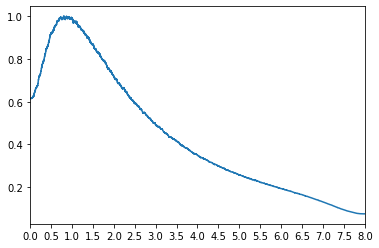

In [10]:
filtered = savgol_filter((xzSpec + yzSpec), 1001, 3)
noiseSpecSmooth = torch.tensor(filtered)
noiseSpecSmooth = noiseSpecSmooth / noiseSpecSmooth.abs().max()
plt.plot(noiseSpecSmooth.abs(), label="xz")
xlim = maxLen //2 + 1
xlimHz = xlim * Fs / maxLen
xticksHz = torch.arange(0, xlimHz + 1, 500)
xticks = xticksHz * maxLen / Fs
xticks_labels = [f"{x/1000:.1f}" for x in xticksHz]
plt.xlim(0, xlim)
plt.xticks(xticks, xticks_labels)
plt.show()

/home/tsu/.local/lib/python3.10/site-packages/scipy/signal/_savitzky_golay.py:339: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(np.float64)
/home/tsu/.miniforge3/envs/micemouse/lib/python3.10/site-packages/torch/_tensor.py:1032: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)


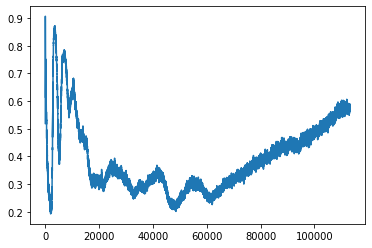

In [11]:
ratio = mouseYSpec/noiseSpecSmooth
ratio[:10_000] = ratio[10_000]
# running average
ratio = savgol_filter(ratio, 1001, 3)
newNoiseSpec = noiseSpecSmooth * (ratio.mean())
H = gtSpec / (gtSpec + newNoiseSpec)
plt.plot(H)

 12%|███████████████████████████████▋                                                                                                                                                                                                                                                 | 1036/8942 [05:13<00:28, 279.07it/s]

 14%|█████████████████████████████████████▉                                                                                                                                                                                                                                           | 1243/8942 [05:13<00:15, 484.40it/s]

 20%|██████████████████████████████████████████████████████▋                                                                                                                                                                                                                          | 1791/8942 [07:44<00:53, 133.70it/s]

 25%|███████████████████████████████████████████████████████████████████▉                                                                                                                                                                                                             | 2225/8942 [07:45<00:12, 544.84it/s]

 28%|███████████████████████████████████████████████████████████████████████████▊                                                                                                                                                                                                     | 2482/8942 [07:45<00:11, 573.37it/s]

...

 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                                                             | 6410/8942 [25:58<03:13, 13.11it/s]

 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                             | 6415/8942 [25:59<03:46, 11.16it/s]

 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                                                             | 6419/8942 [25:59<04:29,  9.37it/s]

 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                             | 6424/8942 [26:00<03:48, 11.02it/s]/home/tsu/saki/research/Mic-E-Mouse/core/signal/preprocess.py:15: UserWarning: loadtxt: input contained no data: "vctk/gen/csv/wav48_silence_trimmed/p229/p229_180_mic2.csv"
  data = np.loadtxt(src, delimiter=',',skiprows=1,dtype=int)
 72%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                                                             | 6426/8942 [26:00<10:10,  4.12it/s]

IndexError: too many indices for tensor of dimension 1

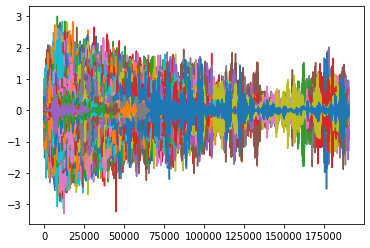

In [16]:
for csv_i in tqdm(range(len(collectedCSV))):

    if (os.path.getsize(collectedCSV[csv_i]) == 0):
        tqdm.write("WARNING: zero-length - [{}]".format(collectedCSV[csv_i]))
        continue
    #pbar.update(1)
    
    
    _, xtest, ytest = processFromFile(collectedCSV[csv_i], skipPCA= True)
    origLen = xtest.shape[-1]
    xtest = F.pad(xtest, (0, maxLen - xtest.shape[-1]))
    ytest = F.pad(ytest, (0, maxLen - ytest.shape[-1]))
    xtestSpec = torch.fft.rfft(xtest)
    ytestSpec = torch.fft.rfft(ytest)
    testSpec = (xtestSpec + ytestSpec) * H
    test = torch.fft.irfft(testSpec)
    test = test[:origLen]
    test = torch.tensor(wiener(test, 1001, 0.2))
    
    Path(os.path.dirname(exportedFLAC[csv_i])).mkdir(parents=True, exist_ok=True)
    #print(exportedFLAC[csv_i])

    
    plt.plot(test[24000:-12000])
    test = test[24000:-12000]
    #torchaudio.save(exportedFLAC[csv_i], torch.tensor(test.unsqueeze(0), dtype=torch.float32), Fs)
    #break
    torchaudio.save(exportedFLAC[csv_i], test.unsqueeze(0).clone().detach(), Fs)
# plt.plot(ytest)